#  Imports & Setup

In [51]:
#  Setup & Imports
import os
import random
import string
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from zipfile import ZipFile
from PIL import Image
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Downloading the necessary resources for nltk
nltk.download('punkt')

# GPU or CPU 
device = "cuda" if torch.cuda.is_available() else "cpu"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#  Dataset Paths & Extraction

In [52]:
# from google.colab import drive
# drive.mount('/content/drive')
# dataset_zip = "/content/drive/MyDrive/Documents/Flickr8k_Dataset.zip"
# captions_zip = "/content/drive/MyDrive/Documents/Flickr8k_text.zip"

# with ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall("/content/Flickr8k_Dataset")
# with ZipFile(captions_zip, 'r') as zip_ref:
#     zip_ref.extractall("/content/Flickr8k_text")


# Load Captions & Build Vocabulary

In [ ]:
# Directories of the dataset and captions
image_dir = "Flickr8k_Dataset/Flicker8k_Dataset"
caption_file = "Flickr8k_text/Flickr8k.token.txt"

# captions { image_id: [caption1, caption2, ...] }
captions = {}
with open(caption_file, 'r') as f:
    for line in f:
        if len(line) < 2:
            continue
        # take both part of the file id and caption
        img_id, caption = line.split('\t')
        img_id = img_id.split('#')[0].strip()
        # preprocess the caption
        caption = caption.lower().strip().translate(str.maketrans('', '', '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~'))
        captions.setdefault(img_id, []).append(caption)

available_images = list(set(captions.keys()) & set(os.listdir(image_dir)))
selected_imgs = random.sample(available_images, 3000)               # 3000 images for training of vocabulary
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])


#  Vocabulary

In [ ]:
import re
from collections import Counter

def tokenize_text(text):
    # uses a regular expression to split text into words
    return re.findall(r'\b\w+\b', text.lower())  # We put everything in lower case and cut out the words

word_freq = Counter()
for cap_list in captions.values():
    for cap in cap_list:
        tokens = tokenize_text(cap)  # Tokenisation without nltk
        word_freq.update(tokens)

# creating a vocabulary of words that appear at least 3 times
vocab = [w for w in word_freq if word_freq[w] >= 3]
word2idx = {w: i+1 for i, w in enumerate(vocab)}
word2idx["<PAD>"] = 0
word2idx["<START>"] = len(word2idx)
word2idx["<END>"] = len(word2idx)
word2idx["<UNK>"] = len(word2idx)
idx2word = {i: w for w, i in word2idx.items()}


#  Image Captioning with Attention (Full Version)

-  Attention Mechanism
-  ResNet18 Encoder
-  LSTM Decoder
-  BLEU Score Evaluation
-  Top-k Sampling
-  Heatmap of Attention

<!-- from google.colab import drive
drive.mount('/content/drive')

# Extraction
dataset_zip = "/content/drive/MyDrive/Documents/Flickr8k_Dataset.zip"
captions_zip = "/content/drive/MyDrive/Documents/Flickr8k_text.zip"

with ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/Flickr8k_Dataset")

with ZipFile(captions_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/Flickr8k_text") -->


## Load 

In [ ]:
# dataset for the attention model
captions = {}
with open(caption_file, 'r') as f:
    for line in f:
        if len(line) < 2: continue
        img_id, caption = line.split('\t')
        img_id = img_id.split('#')[0].strip()
        cleaned = caption.lower().strip().translate(str.maketrans('', '', '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~'))
        captions.setdefault(img_id, []).append(cleaned)

available_images = list(set(captions.keys()) & set(os.listdir(image_dir)))
selected_imgs = random.sample(available_images, 2500)  #  Mettre plus si GPU OK


In [56]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from PIL import Image, ImageOps
import os
import torch

# Lettrebox transform preserving aspect ratio
def letterbox(image, size=(128, 128)):
    image.thumbnail(size, Image.LANCZOS)
    delta_w = size[0] - image.size[0]
    delta_h = size[1] - image.size[1]
    padding = (
        delta_w // 2,
        delta_h // 2,
        delta_w - (delta_w // 2),
        delta_h - (delta_h // 2),
    )
    return ImageOps.expand(image, padding, fill=0)

transform = transforms.Compose([
    transforms.Lambda(lambda img: letterbox(img)),
    transforms.ToTensor()
])

# Dataset personnalisé
class FlickrDataset(Dataset):
    def __init__(self, image_ids):
        self.image_ids = image_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(image_dir, img_id)
        image = self.transform(Image.open(img_path).convert("RGB"))

        # Tokenize caption
        tokens = ["<START>"] + captions[img_id][0].split() + ["<END>"]
        cap_idx = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

        return image, torch.tensor(cap_idx)

# Collate function pour padding dynamique
def collate_fn(batch):
    images, captions = zip(*batch)
    captions = pad_sequence(captions, padding_value=word2idx["<PAD>"])
    return torch.stack(images), captions

# Dataloader
dataloader = DataLoader(
    FlickrDataset(selected_imgs),
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)


In [ ]:
# model definition

class EncoderCNN(nn.Module):
    def __init__(self, encoded_size=14):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # Conserve le spatial
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_size, encoded_size))  # Ex: 14x14

    def forward(self, x):
        x = self.backbone(x)  # (B, 512, H, W)
        x = self.adaptive_pool(x)  # (B, 512, 14, 14)
        x = x.permute(0, 2, 3, 1)  # (B, 14, 14, 512)
        x = x.view(x.size(0), -1, x.size(-1))  # (B, 196, 512)
        return x



In [58]:
# Attention
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim)
        self.dec_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden_state):
        att1 = self.enc_att(encoder_out)                  # (B, 196, attention_dim)
        att2 = self.dec_att(hidden_state).unsqueeze(1)    # (B, 1, attention_dim)
        e = torch.tanh(att1 + att2)                       # (B, 196, attention_dim)
        alpha = self.full_att(e).squeeze(2)               # (B, 196)
        alpha = torch.softmax(alpha, dim=1)               # (B, 196)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
        return context, alpha



In [ ]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, decoder_dim, vocab_size, encoder_dim=512, attention_dim=256):
        super().__init__()
        # Layers
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, encoder_out, captions):
        # (seq_len, batch_size)
        seq_len = captions.size(0)
        batch_size = captions.size(1)

        # Convert captions to embeddings: (seq_len, batch, E)
        embeddings = self.embed(captions)  

        # Initialize hidden states and cells with batch size
        h = torch.zeros(batch_size, 512).to(encoder_out.device)
        c = torch.zeros(batch_size, 512).to(encoder_out.device)

        outputs = []
        for t in range(seq_len):
            # Getting context through attention
            context, _ = self.attention(encoder_out, h)  # (batch, encoder_dim)
            # Concatenate the current token embedding and the context
            lstm_input = torch.cat([embeddings[t], context], dim=1)  # (batch, embed_size + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))
            output = self.fc(self.dropout(h))
            outputs.append(output)

        # Returns the sequence of outputs in the form (seq_len, batch, vocab_size)
        return torch.stack(outputs, dim=0)


# Entraînement

In [ ]:
#Fiting
device = "cuda" if torch.cuda.is_available() else "cpu"

# Model initialization
encoder = EncoderCNN().to(device) # GPU or CPU
decoder = DecoderLSTM(
    embed_size=256,
    decoder_dim=512,
    vocab_size=len(word2idx),
    encoder_dim=512
).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-3
)

#  Training
EPOCHS = 24
for epoch in range(EPOCHS):
    total_loss = 0
    for i, (img, cap) in enumerate(dataloader):
        img, cap = img.to(device), cap.to(device)
        encoder_out = encoder(img)
        outputs = decoder(encoder_out, cap[:-1])  # prédire t+1 à partir de t
        loss = criterion(outputs.view(-1, outputs.size(-1)), cap[1:].view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if i % 20 == 0:
            print(f" Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")
    print(f" Epoch {epoch+1} completed | Total Loss: {total_loss:.4f}\n")


 Epoch 1, Step 0, Loss: 8.3675
 Epoch 1, Step 20, Loss: 3.1620
 Epoch 1, Step 40, Loss: 2.6830
 Epoch 1, Step 60, Loss: 3.4670
 Epoch 1, Step 80, Loss: 2.5613
 Epoch 1, Step 100, Loss: 2.8393
 Epoch 1, Step 120, Loss: 2.5587
 Epoch 1, Step 140, Loss: 2.5341
 Epoch 1 completed | Total Loss: 479.1446

 Epoch 2, Step 0, Loss: 2.3893
 Epoch 2, Step 20, Loss: 2.4165
 Epoch 2, Step 40, Loss: 2.4494
 Epoch 2, Step 60, Loss: 2.6834
 Epoch 2, Step 80, Loss: 2.4171
 Epoch 2, Step 100, Loss: 2.7728
 Epoch 2, Step 120, Loss: 2.3095
 Epoch 2, Step 140, Loss: 2.2967
 Epoch 2 completed | Total Loss: 376.6085

 Epoch 3, Step 0, Loss: 2.1530
 Epoch 3, Step 20, Loss: 2.0014
 Epoch 3, Step 40, Loss: 1.9691
 Epoch 3, Step 60, Loss: 2.2404
 Epoch 3, Step 80, Loss: 2.0934
 Epoch 3, Step 100, Loss: 2.2925
 Epoch 3, Step 120, Loss: 2.1747
 Epoch 3, Step 140, Loss: 2.2804
 Epoch 3 completed | Total Loss: 329.4747

 Epoch 4, Step 0, Loss: 2.1059
 Epoch 4, Step 20, Loss: 1.7326
 Epoch 4, Step 40, Loss: 2.0131
 E

In [61]:
# generate captions carefully
def generate_caption_attention(image_tensor, max_len=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        encoder_out = encoder(image_tensor)  # (1, 196, 512)
        h = torch.zeros(1, 512).to(device)
        c = torch.zeros(1, 512).to(device)

        caption = []
        alphas = []

        word = torch.tensor([word2idx["<START>"]]).to(device)
        for _ in range(max_len):
            embedding = decoder.embed(word).squeeze(0)  # (256,)
            context, alpha = decoder.attention(encoder_out, h)  # (1, 512), (1, 196)
            lstm_input = torch.cat([embedding, context.squeeze(0)], dim=0).unsqueeze(0)
            h, c = decoder.lstm(lstm_input, (h, c))
            output = decoder.fc(h)
            predicted = output.argmax(1)
            word = predicted
            alphas.append(alpha.view(14, 14).cpu().numpy())
            predicted_word = idx2word[word.item()]
            if predicted_word == "<END>":
                break
            caption.append(predicted_word)
        caption = ' '.join(caption)
        return caption, alphas


### Eval bleu
bleu : métrique pour comparer des textes générés 

In [62]:

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_caption_attention(img_id):
    image = transform(Image.open(os.path.join(image_dir, img_id)).convert("RGB"))
    image_tensor = image.to(device)
    generated,_ = generate_caption_attention(image_tensor)

    references = [cap.lower().strip().split() for cap in captions[img_id]]
    candidate = generated.strip().split()
    bleu = sentence_bleu(references, candidate, smoothing_function=SmoothingFunction().method4)
    return bleu, generated



In [63]:
#eval for ten images
total_bleu = 0
print(" BLEU score avec attention :\n")

for i, img_id in enumerate(selected_imgs[:10]):
    bleu, generated = evaluate_caption_attention(img_id)
    total_bleu += bleu
    print(f"{i+1}.  {img_id}")
    print(f"    Caption générée : {generated}")
    print(f"    BLEU score     : {bleu:.4f}\n")

print(f" Score BLEU moyen (attention) : {total_bleu / 10:.4f}")



 BLEU score avec attention :

1.  1207159468_425b902bfb.jpg
    Caption générée : a man in a red jacket looking out over snowcovered mountains
    BLEU score     : 0.0734

2.  3410899419_4f8dca6f3f.jpg
    Caption générée : a group of people are sitting in some rows of wooden seats
    BLEU score     : 0.1203

3.  2918653119_f535fc25c4.jpg
    Caption générée : a boy in a blue shirt climbs through the mud
    BLEU score     : 0.0332

4.  1084040636_97d9633581.jpg
    Caption générée : a man in a yellow jacket is riding a horse through the mountains
    BLEU score     : 0.0245

5.  106514190_bae200f463.jpg
    Caption générée : a man in a scuba suit holds a box
    BLEU score     : 0.0274

6.  3189251454_03b76c2e92.jpg
    Caption générée : a brown dog is chasing after a yellow ball
    BLEU score     : 0.1642

7.  2090386465_b6ebb7df2c.jpg
    Caption générée : a man in a blue shirt lifts up his tennis racket and smiles
    BLEU score     : 0.0556

8.  3640743904_d14eea0a0b.jpg
    Cap

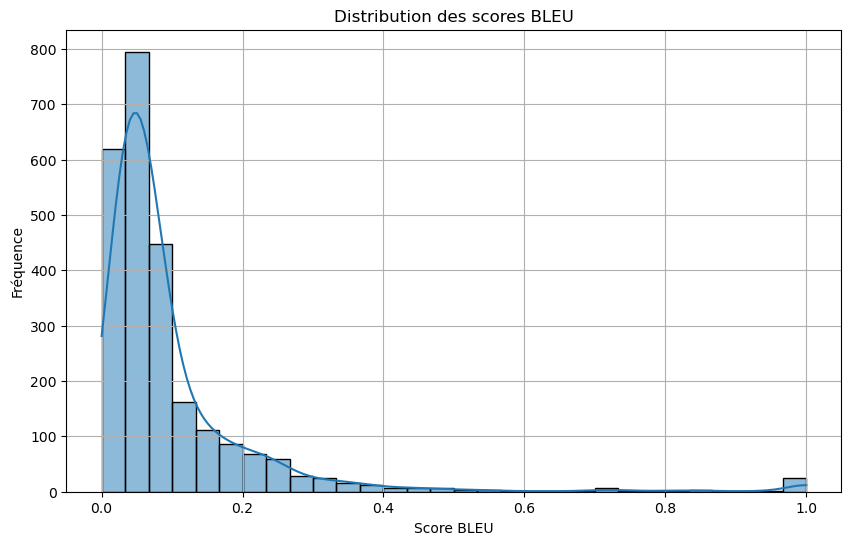

In [64]:
total_bleu = []
for i, img_id in enumerate(selected_imgs):
    bleu, generated = evaluate_caption_attention(img_id)
    total_bleu.append(bleu)

plt.figure(figsize=(10, 6))
sns.histplot(total_bleu, bins=30, kde=True)
plt.title("Distribution des scores BLEU")
plt.xlabel("Score BLEU")    
plt.ylabel("Fréquence")
plt.grid()
plt.show()

## Heatmap of Attention

In [76]:
def visualize_attention(img_path, caption, alphas):
    image = Image.open(img_path).convert("RGB")
    image = image.resize((256, 256))
    fig = plt.figure(figsize=(15, 10))
    for t in range(len(caption)):
        ax = fig.add_subplot(2, (len(caption)+1)//2, t+1)
        ax.set_title(caption[t])
        alpha = alphas[t]
        alpha = Image.fromarray((alpha * 255).astype('uint8')).resize((256, 256), Image.BICUBIC)
        alpha = transforms.ToTensor()(alpha)

        ax.imshow(image)
        ax.imshow(alpha.squeeze(), alpha=0.6, cmap='jet')
        ax.axis("off")

    plt.tight_layout()
    plt.show()


 Caption générée : a brown dog is soaked and is walking out of the water


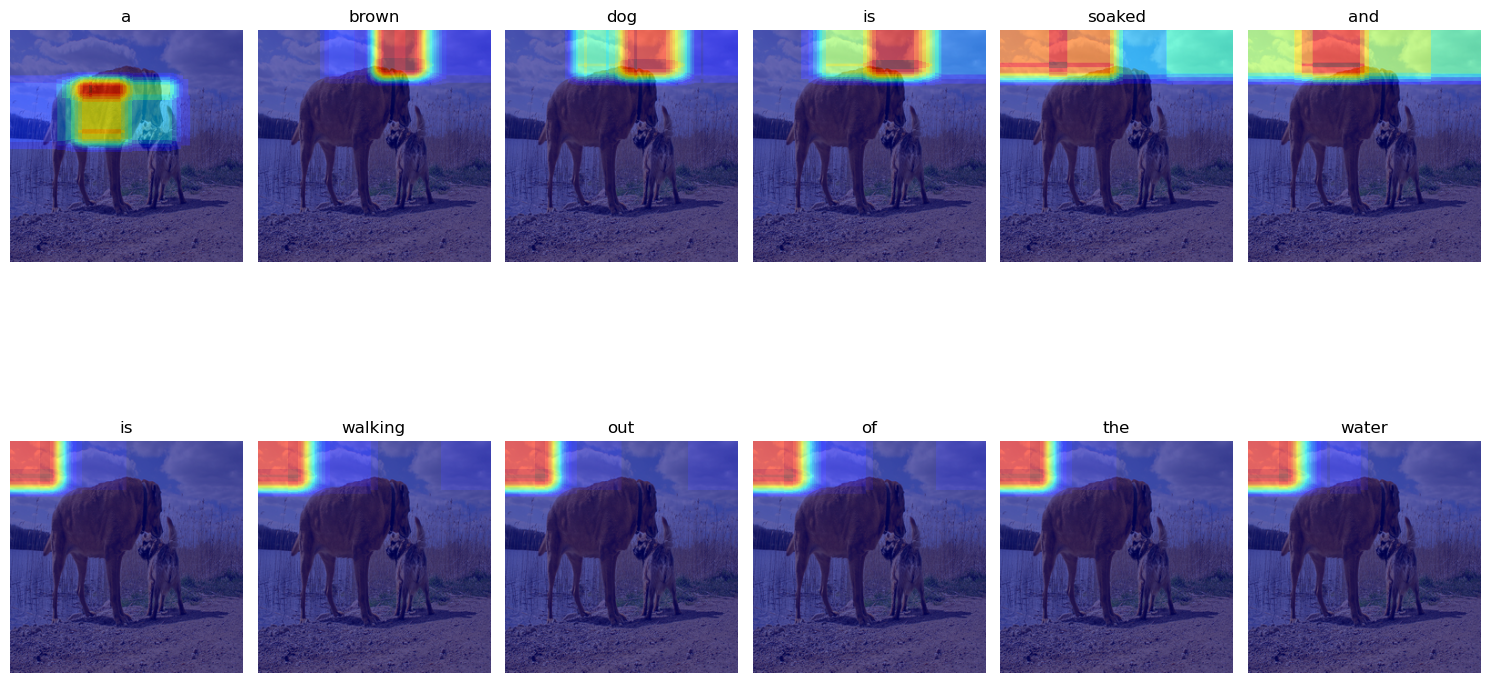

In [78]:
img_id = selected_imgs[10]
img_path = os.path.join(image_dir, img_id)
image_tensor = transform(Image.open(img_path).convert("RGB")).to(device)

caption, alphas = generate_caption_attention(image_tensor)
print(" Caption générée :", caption)
visualize_attention(img_path, caption.split(" "), alphas)
